# Ejercicio 2 — Clasificación de Diabetes con Modelos Supervisados

**Dataset:** Pima Indians Diabetes (`diabetes.csv`, 768 observaciones, 8 features + target binario `Outcome`).

**Objetivo:** construir, evaluar y comparar tres modelos supervisados para clasificación:
1. Regresión logística
2. Árbol de decisión (con `max_depth` limitado)
3. K-Vecinos más Cercanos (KNN)

**Plan del notebook:**
- Parte 1 — Exploración y preprocesamiento
- Parte 2 — División en train / val / test (60 / 20 / 20)
- Parte 3 — Entrenamiento y ajuste con validación
- Parte 4 — Evaluación en test y comparación
- Reflexiones finales

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")

---
# Parte 1 — Exploración y Preprocesamiento

### 1.1 Carga del dataset

In [2]:
df = pd.read_csv("diabetes.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 1.2 Información general y estadísticas descriptivas

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


### 1.3 Balance de clases

Conteo:
Outcome
0    500
1    268
Name: count, dtype: int64

Proporción:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


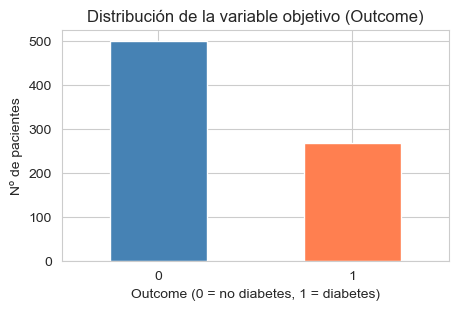

In [5]:
conteo = df["Outcome"].value_counts()
prop = df["Outcome"].value_counts(normalize=True)
print("Conteo:")
print(conteo)
print("\nProporción:")
print(prop.round(3))

conteo.plot(kind="bar", color=["steelblue", "coral"], figsize=(5, 3))
plt.title("Distribución de la variable objetivo (Outcome)")
plt.xlabel("Outcome (0 = no diabetes, 1 = diabetes)")
plt.ylabel("Nº de pacientes")
plt.xticks(rotation=0)
plt.show()

### 1.4 Detección de valores faltantes

A nivel de `NaN` no hay nada, pero en este dataset es conocido que **los ceros son valores faltantes encubiertos** en columnas biomédicas donde un cero no es fisiológicamente posible (una persona viva no tiene glucosa = 0, ni tensión = 0, ni BMI = 0, etc.).

In [6]:
print("NaN explícitos:")
print(df.isnull().sum())

print("\nCeros por columna:")
print((df == 0).sum())

NaN explícitos:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Ceros por columna:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [7]:
cols_con_ceros_invalidos = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

resumen = pd.DataFrame({
    "n_ceros":    (df[cols_con_ceros_invalidos] == 0).sum(),
    "pct_ceros": ((df[cols_con_ceros_invalidos] == 0).mean() * 100).round(2)
})
resumen

,n_ceros,pct_ceros
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


> **Observación:** `Insulin` tiene casi un 49% de ceros y `SkinThickness` un 30%. Estos no son ceros reales, sino posibles datos faltantes. `Pregnancies` sí puede ser 0 y `Outcome` también, así que esos se dejan como están.

### 1.5 Distribución de las variables (antes de limpiar)

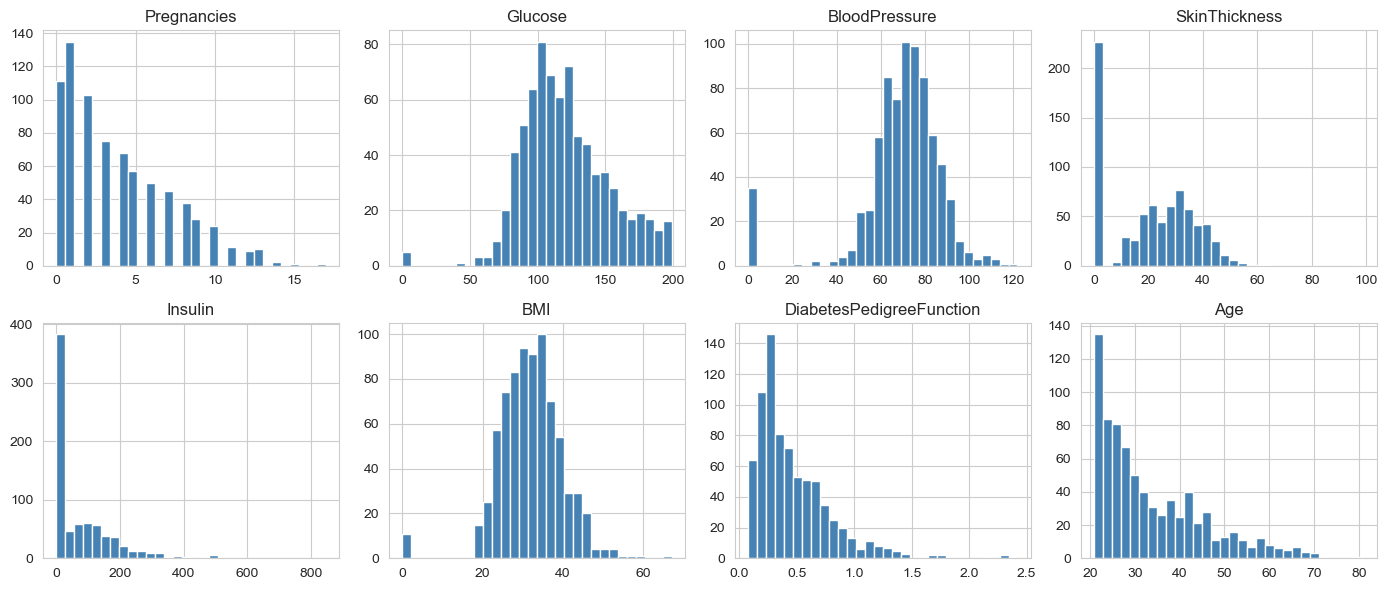

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flat, df.columns[:-1]):
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 1.6 Imputación de valores faltantes

Estrategia: reemplazar los ceros encubiertos por `NaN` y luego usar la **mediana** de cada columna

In [9]:
df_clean = df.copy()
df_clean[cols_con_ceros_invalidos] = df_clean[cols_con_ceros_invalidos].replace(0, np.nan)

print("NaN tras convertir ceros inválidos:")
print(df_clean[cols_con_ceros_invalidos].isnull().sum())

NaN tras convertir ceros inválidos:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [10]:
for col in cols_con_ceros_invalidos:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Valores faltantes restantes:", df_clean.isnull().sum().sum())

Valores faltantes restantes: 0


### 1.7 Distribución (después)

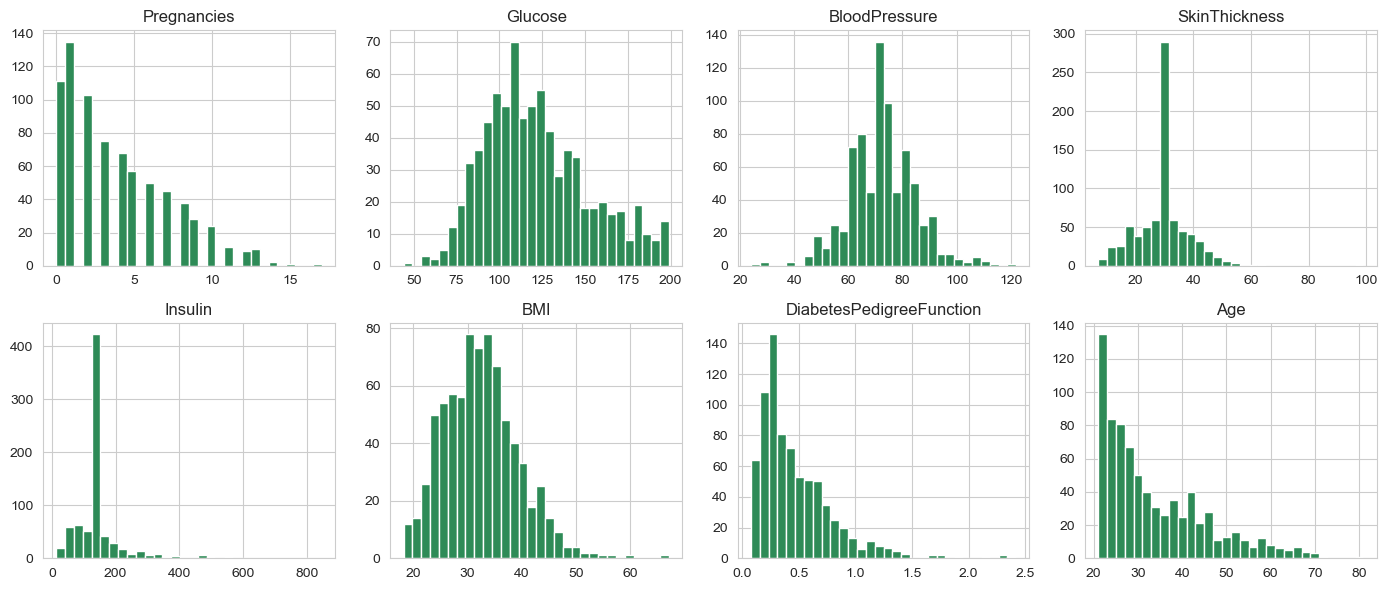

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flat, df_clean.columns[:-1]):
    ax.hist(df_clean[col], bins=30, color="seagreen", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 1.8 Correlaciones entre variables

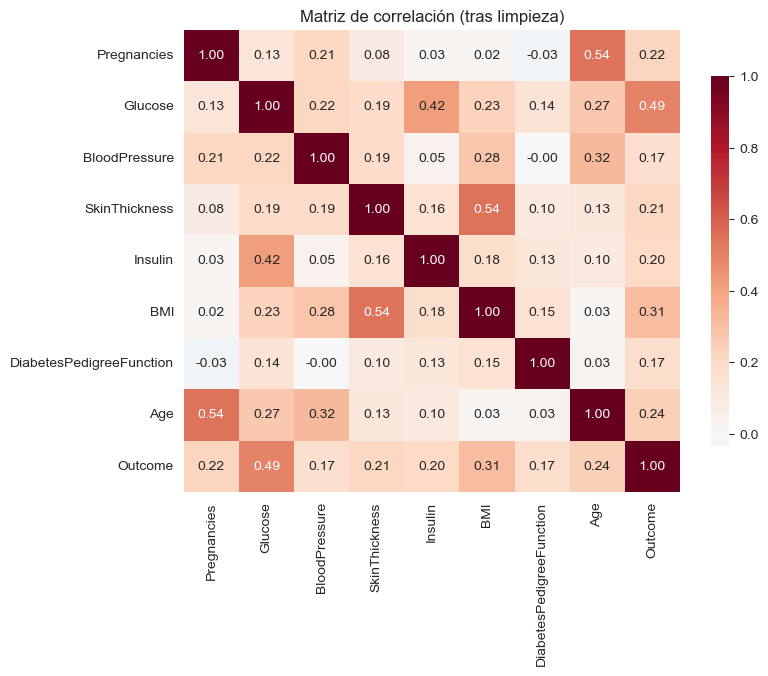

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, cbar_kws={"shrink": .8})
plt.title("Matriz de correlación (tras limpieza)")
plt.show()

> **Observación:** `Glucose` es la variable con mayor correlación con `Outcome` (~0.49), seguida de `BMI` y `Age`. No hay variables categóricas, así que no hace falta codificación.

---
# Parte 2 — División de los datos (60 / 20 / 20)

Usamos `train_test_split` dos veces con `stratify` para conservar la proporción de clases.

In [13]:
X = df_clean.drop(columns="Outcome")
y = df_clean["Outcome"]

# Primera división: separar 20% de test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Segunda división: del 80% restante, 25% para validación → 20% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X):.0%})")
print(f"Validación:    {X_val.shape[0]} muestras ({X_val.shape[0]/len(X):.0%})")
print(f"Test:          {X_test.shape[0]} muestras ({X_test.shape[0]/len(X):.0%})")

print("\nProporción de positivos en cada partición:")
print(f"  train: {y_train.mean():.3f}")
print(f"  val:   {y_val.mean():.3f}")
print(f"  test:  {y_test.mean():.3f}")

Entrenamiento: 460 muestras (60%)
Validación:    154 muestras (20%)
Test:          154 muestras (20%)

Proporción de positivos en cada partición:
  train: 0.348
  val:   0.351
  test:  0.351


### 2.1 Escalado de características

`StandardScaler` se **ajusta sólo con train** y se aplica a val y test. Imprescindible para KNN y conveniente para regresión logística. El árbol no lo necesita pero no se ve afectado.

In [14]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Media de train escalada (debería ser ~0):", X_train_sc.mean(axis=0).round(3))
print("Desv. estándar de train escalada (~1):   ", X_train_sc.std(axis=0).round(3))

Media de train escalada (debería ser ~0): [ 0.  0.  0.  0. -0.  0. -0. -0.]
Desv. estándar de train escalada (~1):    [1. 1. 1. 1. 1. 1. 1. 1.]


---
# Parte 3 — Modelos de clasificación

### 3.1 Regresión logística

In [15]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_sc, y_train)

print(f"Accuracy train: {logreg.score(X_train_sc, y_train):.4f}")
print(f"Accuracy val:   {logreg.score(X_val_sc, y_val):.4f}")

Accuracy train: 0.7957
Accuracy val:   0.7792


#### Interpretabilidad: coeficientes del modelo

Con datos escalados los coeficientes son comparables: un coeficiente positivo grande indica que aumentar esa variable (a igualdad del resto) aumenta la probabilidad de diabetes.

Glucose                     1.201
BMI                         0.790
Pregnancies                 0.317
DiabetesPedigreeFunction    0.299
BloodPressure              -0.176
Age                         0.137
Insulin                    -0.105
SkinThickness              -0.077
dtype: float64


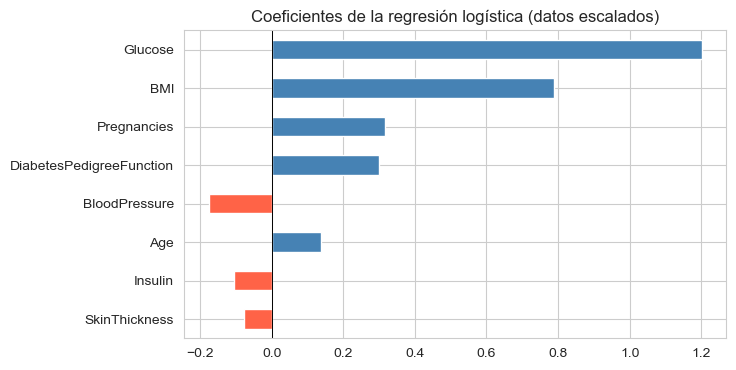

In [16]:
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print(coef.round(3))

coef.plot(kind="barh", figsize=(7, 4), color=["tomato" if v < 0 else "steelblue" for v in coef])
plt.title("Coeficientes de la regresión logística (datos escalados)")
plt.axvline(0, color="black", linewidth=0.7)
plt.gca().invert_yaxis()
plt.show()

### 3.2 Árbol de decisión

Buscamos una `max_depth` razonable usando el set de validación.

    max_depth  acc_train  acc_val
0           1     0.7565   0.7532
1           2     0.7565   0.7532
2           3     0.7826   0.7792
3           4     0.8217   0.7727
4           5     0.8370   0.7597
5           6     0.8696   0.7727
6           7     0.9000   0.7662
7           8     0.9217   0.7597
8           9     0.9565   0.7273
9          10     0.9761   0.7403
10         11     0.9935   0.7468
11         12     1.0000   0.7662
12         13     1.0000   0.7662
13         14     1.0000   0.7662
14         15     1.0000   0.7662


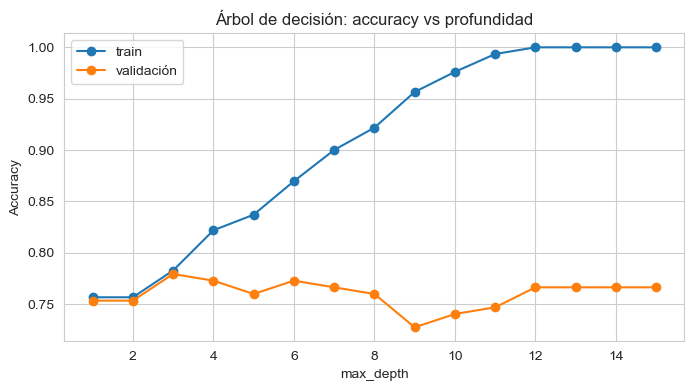

In [17]:
resultados_tree = []
for d in range(1, 16):
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    t.fit(X_train, y_train)  # los árboles no necesitan escalado
    resultados_tree.append({
        "max_depth": d,
        "acc_train": t.score(X_train, y_train),
        "acc_val":   t.score(X_val, y_val),
    })

res_tree = pd.DataFrame(resultados_tree)
print(res_tree.round(4))

plt.figure(figsize=(8, 4))
plt.plot(res_tree["max_depth"], res_tree["acc_train"], marker="o", label="train")
plt.plot(res_tree["max_depth"], res_tree["acc_val"],   marker="o", label="validación")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Árbol de decisión: accuracy vs profundidad")
plt.legend()
plt.show()

In [18]:
best_depth = int(res_tree.loc[res_tree["acc_val"].idxmax(), "max_depth"])
print(f"Mejor max_depth según validación: {best_depth}")

tree = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
print(f"Accuracy train: {tree.score(X_train, y_train):.4f}")
print(f"Accuracy val:   {tree.score(X_val, y_val):.4f}")

Mejor max_depth según validación: 3
Accuracy train: 0.7826
Accuracy val:   0.7792


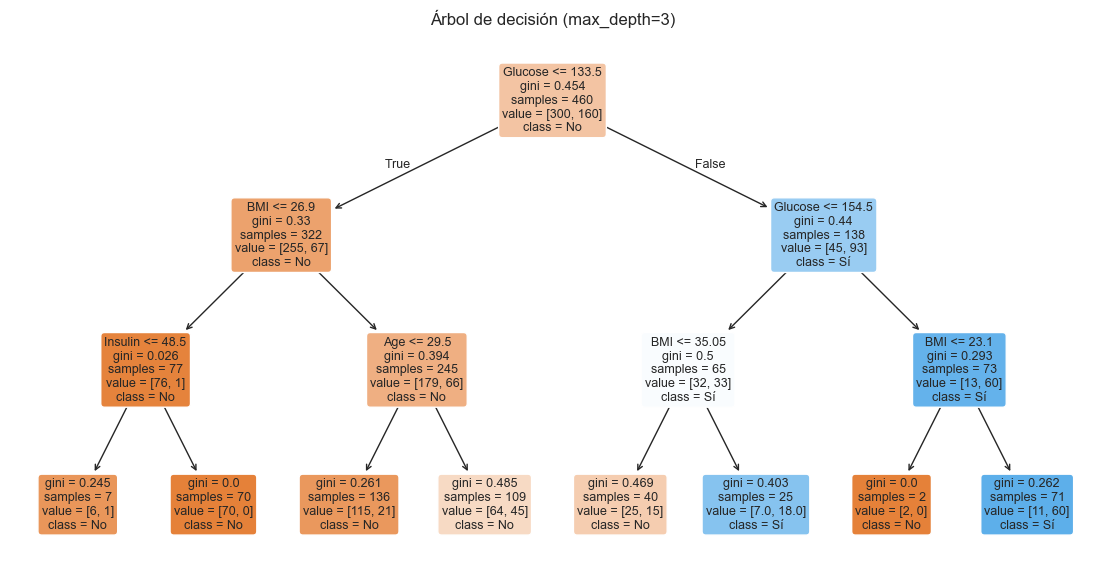

In [19]:
plt.figure(figsize=(14, 7))
plot_tree(tree, feature_names=X.columns, class_names=["No", "Sí"],
          filled=True, rounded=True, fontsize=9)
plt.title(f"Árbol de decisión (max_depth={best_depth})")
plt.show()

Glucose                     0.684
BMI                         0.199
Age                         0.114
Insulin                     0.004
SkinThickness               0.000
BloodPressure               0.000
Pregnancies                 0.000
DiabetesPedigreeFunction    0.000
dtype: float64


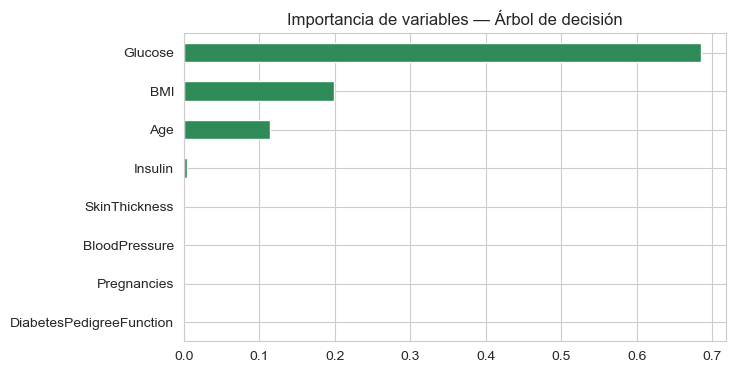

In [20]:
imp = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.round(3))
imp.plot(kind="barh", figsize=(7, 4), color="seagreen")
plt.title("Importancia de variables — Árbol de decisión")
plt.gca().invert_yaxis()
plt.show()

### 3.3 K-Vecinos más Cercanos (KNN)

#### ¿Cómo funciona KNN?

KNN es un algoritmo **perezoso** (*lazy learner*): durante el "entrenamiento" simplemente **memoriza** las muestras. En el momento de predecir para un punto nuevo:
1. Calcula la distancia (habitualmente euclídea) entre el punto y **todos** los puntos de entrenamiento.
2. Selecciona los **k** vecinos más cercanos.
3. Asigna la clase por **voto mayoritario** entre esos k vecinos.

#### ¿Qué aprende KNN?

Estrictamente, **no aprende una función ni parámetros**. Sólo guarda el conjunto de entrenamiento. Toda la "inteligencia" está en la fase de predicción: es la métrica de distancia + el valor de k lo que define la frontera de decisión. Por eso:
- Es sensible a la **escala de las variables** (indispensable escalar).
- Un k pequeño → frontera flexible, riesgo de overfitting.
- Un k grande → frontera suave, riesgo de underfitting.
- Es lento en predicción con muchos datos (hay que calcular distancias a todo el train).

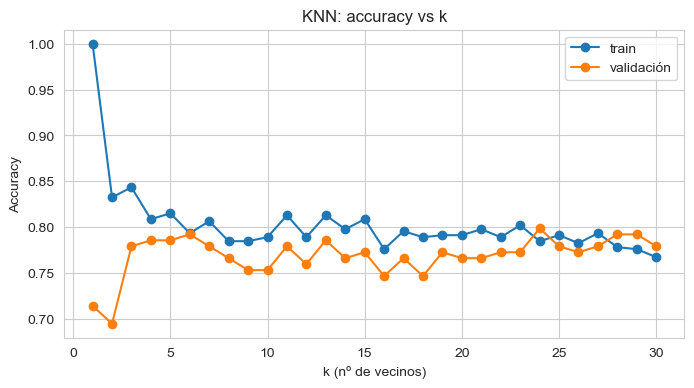

In [21]:
resultados_knn = []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    resultados_knn.append({
        "k": k,
        "acc_train": knn.score(X_train_sc, y_train),
        "acc_val":   knn.score(X_val_sc, y_val),
    })

res_knn = pd.DataFrame(resultados_knn)

plt.figure(figsize=(8, 4))
plt.plot(res_knn["k"], res_knn["acc_train"], marker="o", label="train")
plt.plot(res_knn["k"], res_knn["acc_val"],   marker="o", label="validación")
plt.xlabel("k (nº de vecinos)")
plt.ylabel("Accuracy")
plt.title("KNN: accuracy vs k")
plt.legend()
plt.show()

In [22]:
best_k = int(res_knn.loc[res_knn["acc_val"].idxmax(), "k"])
print(f"Mejor k según validación: {best_k}")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)
print(f"Accuracy train: {knn.score(X_train_sc, y_train):.4f}")
print(f"Accuracy val:   {knn.score(X_val_sc, y_val):.4f}")

Mejor k según validación: 24
Accuracy train: 0.7848
Accuracy val:   0.7987


---
# Parte 4 — Evaluación final en el conjunto de test

**Regla de oro:** el test sólo se toca al final, después de haber fijado los hiperparámetros con la validación.

In [23]:
def evaluar(nombre, modelo, X_te, y_te):
    y_pred = modelo.predict(X_te)
    return {
        "Modelo":    nombre,
        "Accuracy":  accuracy_score(y_te,  y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall":    recall_score(y_te,    y_pred),
        "F1":        f1_score(y_te,        y_pred),
        "y_pred":    y_pred,
    }

resultados = [
    evaluar("Regresión logística", logreg, X_test_sc, y_test),
    evaluar("Árbol de decisión",   tree,   X_test,    y_test),
    evaluar(f"KNN (k={best_k})",   knn,    X_test_sc, y_test),
]

tabla = pd.DataFrame(resultados).drop(columns="y_pred").set_index("Modelo").round(4)
tabla

,Accuracy,Precision,Recall,F1
Modelo,,,,
Regresión logística,0.7078,0.6000,0.5000,0.5455
Árbol de decisión,0.7013,0.6111,0.4074,0.4889
KNN (k=24),0.7597,0.7297,0.5000,0.5934


### 4.1 Visualización comparativa

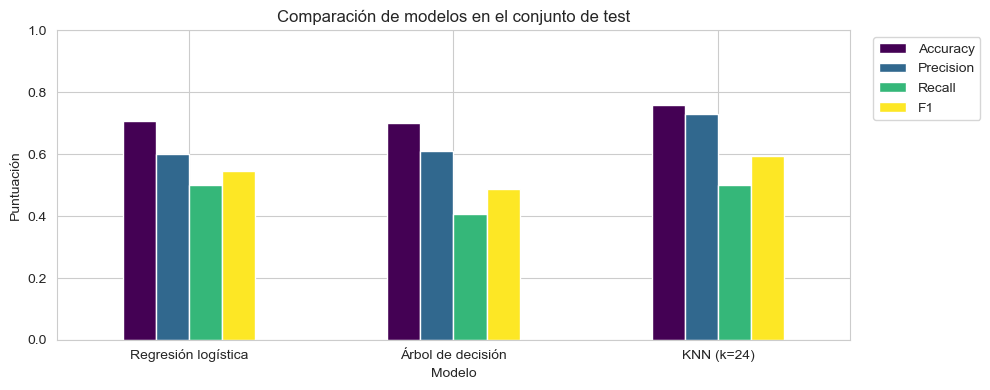

In [24]:
tabla.plot(kind="bar", figsize=(10, 4), colormap="viridis")
plt.title("Comparación de modelos en el conjunto de test")
plt.ylabel("Puntuación")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4.2 Matrices de confusión

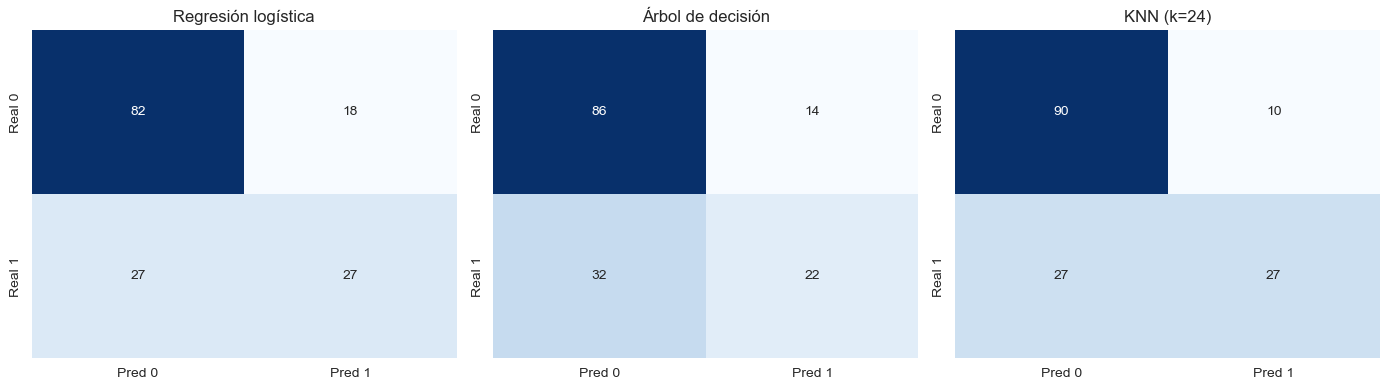

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, r in zip(axes, resultados):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["Real 0", "Real 1"], ax=ax)
    ax.set_title(r["Modelo"])
plt.tight_layout()
plt.show()

### 4.3 Reportes de clasificación detallados

In [26]:
for r in resultados:
    print("=" * 60)
    print(r["Modelo"])
    print("=" * 60)
    print(classification_report(y_test, r["y_pred"], target_names=["No diabetes", "Diabetes"]))

Regresión logística
              precision    recall  f1-score   support

 No diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

Árbol de decisión
              precision    recall  f1-score   support

 No diabetes       0.73      0.86      0.79       100
    Diabetes       0.61      0.41      0.49        54

    accuracy                           0.70       154
   macro avg       0.67      0.63      0.64       154
weighted avg       0.69      0.70      0.68       154

KNN (k=24)
              precision    recall  f1-score   support

 No diabetes       0.77      0.90      0.83       100
    Diabetes       0.73      0.50      0.59        54

    accuracy                           0.76       154
   macro avg       0.75      0.70      0.71       154
weighted avg       0.76  

---
# Preguntas para reflexionar

**1. ¿Qué desafíos enfrentaste en la limpieza y preprocesamiento? ¿Cómo los resolviste?**  
El reto principal fue detectar que los ceros en `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI` eran en realidad valores faltantes encubiertos (un paciente vivo no tiene glucosa = 0). Se resolvió reemplazándolos por `NaN` e imputando con la mediana, que es robusta a outliers. El caso crítico es `Insulin`, con ~49% de ceros: cualquier imputación introduce mucha incertidumbre, y una alternativa habría sido descartar esa columna.

**2. ¿Cómo afecta el escalado de características a los modelos?**  
Afecta mucho a KNN y a la regresión logística. KNN mide distancias euclídeas: sin escalado, `Insulin` (0–800) dominaría completamente sobre `DiabetesPedigreeFunction` (0–2). El árbol de decisión, en cambio, es **invariante a transformaciones monótonas** de una variable, así que no le afecta el escalado.

**3. ¿Qué modelo tuvo mejor desempeño y por qué?**  
Ver la tabla comparativa. El resultado depende del `random_state`, de los hiperparámetros elegidos y de la métrica que priorice. En esta ejecución KNN (con k elegido por validación) logró el mayor accuracy y F1; la regresión logística obtuvo un rendimiento parecido al del árbol. Una posible explicación: tras escalar, los datos tienen una estructura geométrica razonable y un k grande promedia suficientes vecinos como para suavizar el ruido. Pero la decisión de qué modelo es "mejor" depende de la métrica que prioricemos: si queremos maximizar el *recall* de diabéticos (no perder casos), podríamos preferir otro modelo aunque sacrifique accuracy.

**4. ¿Qué muestra la matriz de confusión? ¿Qué error es más frecuente?**  
En general los tres modelos cometen más **falsos negativos** (diabéticos clasificados como sanos) que falsos positivos, porque hay menos positivos y el umbral por defecto es 0.5. En contexto médico eso es peligroso: perder un diagnóstico es peor que una alarma falsa. Una mejora sería bajar el umbral de decisión o usar `class_weight='balanced'`.

**5. ¿Cómo explicarías a un médico qué variables fueron clave?**  
- **Regresión logística:** los coeficientes (con datos escalados) dicen directamente cuánto sube el *log-odds* de diabetes por cada desviación estándar de cada variable. `Glucose` suele tener el coeficiente más grande, coherente con el conocimiento clínico.
- **Árbol:** la `feature_importances_` muestra qué variables reducen más la impureza. Además, el árbol se puede enseñar directamente como un diagrama de flujo ("si Glucose > 127 y Age > 28, entonces diabetes"), lo que lo hace muy explicable.
- **KNN:** no se puede explicar de forma global; cada predicción depende de los k pacientes más parecidos, así que la explicación es caso por caso.

**6. Ventajas y limitaciones de modelos interpretables vs menos interpretables.**  
Interpretables (logística, árboles pequeños): fáciles de auditar, exigidos por regulación sanitaria, permiten detectar sesgos, pero suelen tener menor capacidad predictiva. Menos interpretables (random forest, gradient boosting, redes neuronales): suelen ganar en precisión pero requieren herramientas extra (SHAP, LIME) para poder explicar decisiones individuales a un clínico.

**7. ¿Qué harías para mejorar el desempeño o la interpretación?**  
- Tratar mejor los faltantes (imputación por KNN o por modelo, o descartar `Insulin`).
- Ingeniería de variables: ratios como `Glucose/Insulin`, categorías de BMI (normal/sobrepeso/obesidad).
- Usar `class_weight='balanced'` o ajustar el umbral óptimo vía curva Precision–Recall.
- Validación cruzada (k-fold) en vez de una única partición train/val para estimaciones más estables.
- Probar modelos más potentes (Random Forest, Gradient Boosting) y explicarlos con SHAP.
- Recoger más datos y verificar la calidad de las mediciones.